# SMOTE and Tomek Links for imbalanced data

In [1]:
from matplotlib import pyplot as plt
import seaborn as sns
from IPython.display import Image

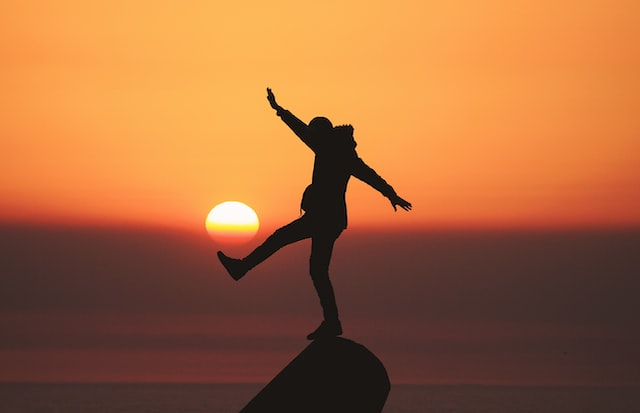

## Table of Contents

* 1. Introduction
    * 1.1 SMOTE (Synthetic Minority Oversampling Technique)
    * 1.2 Undersampling using Tomek Links
    * 1.3 Combination of SMOTE and Timek Links
* 2. Set-up
    * 2.1 Import Libraries
    * 2.2 Import Data
    * 2.3 Data Sets Characteristics
    * 2.4 Data imbalance check
    * 2.5 99,8% Accuracy score before implementing any model
* 3. Data pre-processing
    * 3.1 Dropping duplicated values
    * 3.2 Oversample/undersample before or after splitting data?
    * 3.3 Train test split - you could have been splitting your dataset all wrong
    * 3.4 Feature scaling
* 4. SMOTE-Tomek Implementation
    * 4.1 Oversample/undersample and Cross Validation
    * 4.2 Optimising for Recall
    * 4.3 Training model
    * 4.4 GridSearchCV
    * 4.5 Confusion matrix and scores
    * 4.6 Summary
    * 4.7 AUC-ROC Curve
    * 4.8 Precision-Recall Curve (PR curve)
* 5. My other notebooks recommendations
* 6. Referrals

# 1. Introduction

## 1.1 SMOTE (Synthetic Minority Oversampling Technique)

SMOTE (Synthetic Minority Oversampling Technique) is one of the most commonly used oversampling methods to solve the imbalance problem. This technique was described by Nitesh Chawla, et al. in their 2002 paper named for the technique titled “SMOTE: Synthetic Minority Over-sampling Technique.”

SMOTE synthesize elements for the minority class. The algorithm works by selecting examples that are close in the feature space, drawing a line between the examples in the feature space and drawing a new sample at a point along that line.

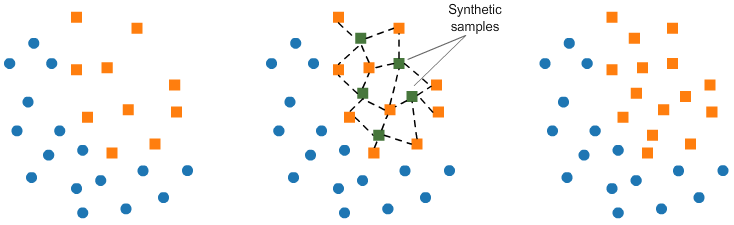

# 1.2 Undersampling using Tomek Links

Tomek Links is an under-sampling technique that was developed in 1976 by Ivan Tomek. It is one of a modification from Condensed Nearest Neighbors (CNN). It can be used to find desired samples of data from the majority class that is having the lowest Euclidean distance with the minority class data and then remove it.

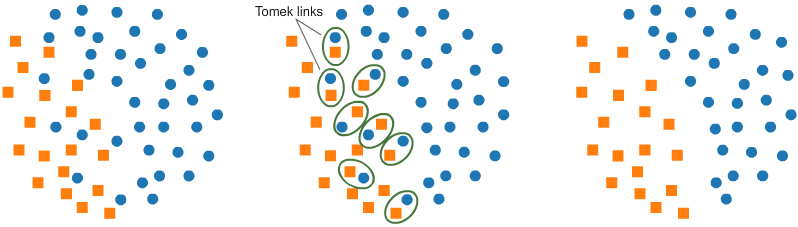

# 1.3 Combination of SMOTE and Timek Links

A combination of over-sampling the minority (abnormal) class and under-sampling the majority (normal) class can achieve better classifier performance than only under-sampling the majority class. This method was first introduced by Batista et al. (2003).

The process of SMOTE-Tomek Links is as follows.

1. Start of SMOTE: choose random data from the minority class.
2. Calculate the distance between the random data and its k nearest neighbors.
3. Multiply the difference with a random number between 0 and 1, then add the result to the minority class as a synthetic sample.
4. Repeat step number 2–3 until the desired proportion of minority class is met (End of SMOTE).
5. Start of Tomek Links: choose random data from the majority class.
6. If the random data’s nearest neighbor is the data from the minority class (i.e. create the Tomek Link), then remove the Tomek Link.

# 2 Set-up

## 2. 1 Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

## 2.2 Import Data

In [3]:
try:
    raw_df = pd.read_csv('../input/creditcardfraud/creditcard.csv')
except:
    raw_df = pd.read_csv('creditcard.csv')

## 2.3 Data Set Characteristics

### Context

It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

### Content

The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

## 2.4 Data imbalance check

In [4]:
labels=["Genuine","Fraud"]

fraud_or_not = raw_df["Class"].value_counts().tolist()
values = [fraud_or_not[0], fraud_or_not[1]]

fig = px.pie(values=raw_df['Class'].value_counts(), names=labels , width=700, height=400, color_discrete_sequence=["skyblue","black"]
             ,title="Fraud vs Genuine transactions")
fig.show()

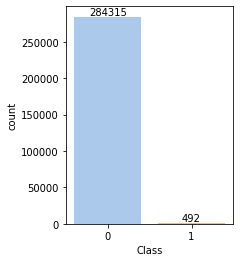

In [5]:
plt.figure(figsize=(3,4))
ax = sns.countplot(x='Class',data=raw_df,palette="pastel")
for i in ax.containers:
    ax.bar_label(i,)

In [6]:
print('Genuine:', round(raw_df['Class'].value_counts()[0]/len(raw_df) * 100,2), '% of the dataset')
print('Frauds:', round(raw_df['Class'].value_counts()[1]/len(raw_df) * 100,2), '% of the dataset')

Genuine: 99.83 % of the dataset
Frauds: 0.17 % of the dataset


## 2.5 99,8% Accuracy score before implementing any model

Don't use accuracy score as a metric with imbalanced datasets - it will be usually high and misleading. In this dataset:

* we have **99,8%** of Genuine transactions and only **0,173%** (492) of fraud transactions;

* whis means that a blind guess (bet on Genuine) would give us accuracy of **99,8%**.

# 3. Data pre-processing

The description of the data says that all the features went through a PCA transformation (Dimensionality Reduction technique) except for 'time' and 'Amount'.

For PCA features need to be previously scaled so we can assume that they are (except for 'time' and 'Amount').

## 3.1 Dropping duplicated values

In [7]:
df = raw_df.copy()

df.drop_duplicates(inplace=True)
print("Duplicated values dropped succesfully")
print("*" * 100)

Duplicated values dropped succesfully
****************************************************************************************************


In [8]:
df = df.drop('Time', axis=1)

## 3.2 Oversample/undersample before or after splitting data?

The rule of thumb is: **never mess up with your test set**. Always split into test and train sets BEFORE trying oversampling/undersampling techniques!

Oversampling before splitting the data can allow the exact same observations to be present in both the test and train sets. This can allow model to simply memorize specific data points and cause overfitting and poor generalization to the test data. Data leakage can cause you to create overly optimistic if not completely invalid predictive models.

1. 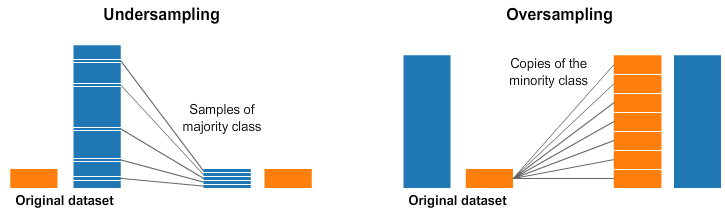

## 3.3 Train test split

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size = 0.3, random_state = 42)

## 3.4. Feature scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# Creating function for scaling
def Standard_Scaler (df, col_names):
    features = df[col_names]
    scaler = StandardScaler().fit(features.values)
    features = scaler.transform(features.values)
    df[col_names] = features
    
    return df

In [12]:
col_names = ['Amount']
X_train = Standard_Scaler (X_train, col_names)
X_test = Standard_Scaler (X_test, col_names)

# 4. SMOTE-Tomek Implementation

## 4.1 Oversample/undersample and Cross Validation

If you want to undersample or oversample your data you shouldn't do it before cross validating because you will be directly influencing the validation set before implementing cross-validation causing a "data leakage" problem.

Exactly like we should do feature selection inside the cross validation loop, we should also oversample inside the loop.

In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
#We are going to ensure that we have the same splits of the data every time. 
#We can ensure this by creating a KFold object, kf, and passing cv=kf instead of the more common cv=5.

kf = StratifiedKFold(n_splits=5, shuffle=False)

## 4.2 Optimising for Recall

Recall: **The ability of a model to find all the relevant cases within a data set**. The number of true positives divided by the number of true positives plus the number of false negatives.

In most high-risk detection cases (like cancer), recall is a more important evaluation metric than precision.

In the case of credit card fraud detection, we want to avoid false negatives as much as possible. Fraud transactions cost us a lot and thus we want to take appropriate measures to prevent them. A false negative case means that a fraud-positive transaction is assessed to genuine transaction, which is detrimental. In this use case, false positives (a genuine transaction as fraud-positive) are not as important as preventing a fraud.

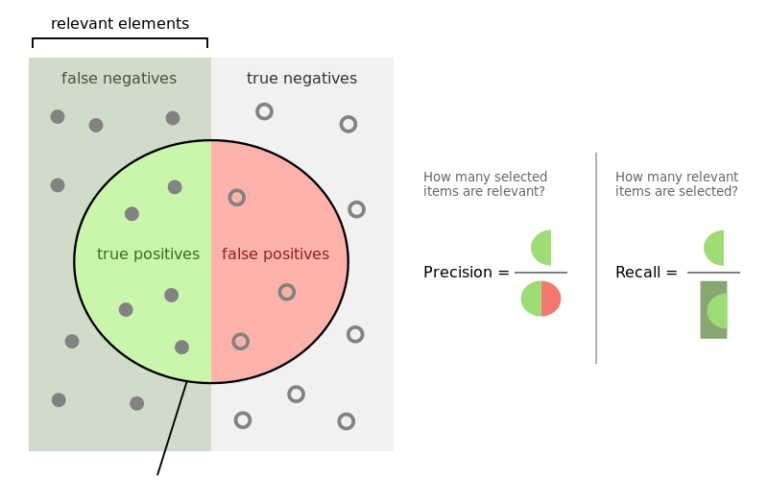

## 4.3 Training model

In [14]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline, make_pipeline

SMOTETomek_pipeline = make_pipeline(SMOTETomek(tomek=TomekLinks(sampling_strategy='majority')), 
                              RandomForestClassifier(n_estimators=50, max_depth=6, random_state=13))

In [15]:
#### This part of the code wasn't executed
# score = cross_val_score(SMOTETomek_pipeline, X_train, y_train, scoring='recall', cv=kf)
# print("Cross Validation Recall Scores are: {}".format(score))
# print("Average Cross Validation Recall score: {}".format(score.mean()))

## 4.4 GridSearchCV

GridSearchCV combined with SMOTE-Tomek and k-fold Cross-Validation is computationally very demanding. It takes more than 12 hours and that's impossible for Kaggle. That's why I did the computations on my local Yupyter Notebook and used best GridSearchCV parameters to fit the model.

You can find the formula for GridSearchCV below.

In [16]:
SMOTETomek_rf = SMOTETomek_pipeline
SMOTETomek_rf.fit(X_train, y_train)

Pipeline(steps=[('smotetomek',
                 SMOTETomek(tomek=TomekLinks(sampling_strategy='majority'))),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=6, n_estimators=50,
                                        random_state=13))])

In [17]:
#### This part of the code wasn't executed
# from sklearn.model_selection import GridSearchCV

#params = {
#    'n_estimators': [50, 100, 200],
#    'max_depth': [4, 6, 10, 12],
#    'random_state': [13]
#}

In [18]:
#### This part of the code wasn't executed
# new_params = {'randomforestclassifier__' + key: params[key] for key in params}
# SMOTETomek_rf = GridSearchCV(SMOTETomek_pipeline, param_grid=new_params, cv=kf, scoring='recall',
#                         return_train_score=True)
# SMOTETomek_rf.fit(X_train, y_train)

## 4.5 Confusion matrix and scores

In [19]:
y_pred = SMOTETomek_rf.predict(X_test)

In [20]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score

cm = confusion_matrix(y_test, y_pred)

SMOTETomek_rf_Recall = recall_score(y_test, y_pred)
SMOTETomek_rf_Precision = precision_score(y_test, y_pred)
SMOTETomek_rf_f1 = f1_score(y_test, y_pred)
SMOTETomek_rf_accuracy = accuracy_score(y_test, y_pred)

print(cm)

[[84657   319]
 [   21   121]]


In [21]:
ndf = [(SMOTETomek_rf_Recall, SMOTETomek_rf_Precision, SMOTETomek_rf_f1, SMOTETomek_rf_accuracy)]

SMOTETomek_rf_score = pd.DataFrame(data = ndf, columns=['Recall','Precision','F1 Score', 'Accuracy'])
SMOTETomek_rf_score.insert(0, 'Random Forest with', 'SMOTE + Tomek')
SMOTETomek_rf_score

,Random Forest with,Recall,Precision,F1 Score,Accuracy
0,SMOTE + Tomek,0.852113,0.275,0.415808,0.996006


## 4.6 Summary

SMOTE-Tomek achived 84% Recall score, but it costs us a lot: Precision 0,28 and F1 Score: 0,42.

**Can we achive better results?**

Probably yes - there is much more to do when it comes to K-Fold Cross Validation and tuning hyperparameters. 

## 4.7 AUC-ROC Curve

AUC (Area Under The Curve) ROC (Receiver Operating Characteristics) curve.

ROC is a probability curve and AUC represents the degree or measure of separability. It tells how much the model is capable of distinguishing between classes. Higher the AUC, the better the model is at predicting 0 classes as 0 and 1 classes as 1.

The ROC curve is plotted with TPR against the FPR where TPR is on the y-axis and FPR is on the x-axis.

An excellent model has AUC near to the 1 which means it has a good measure of separability. A poor model has an AUC near 0 which means it has the worst measure of separability.

* When AUC is 0.7, it means there is a 70% chance that the model will be able to distinguish between positive class and negative class.
* When AUC is approximately 0.5, the model has no discrimination capacity to distinguish between positive class and negative class.
* When AUC is approximately 0, the model is predicting a negative class as a positive class and vice versa.

In [22]:
from sklearn.metrics import roc_auc_score
ROCAUCscore = roc_auc_score(y_test, y_pred)
print(f"AUC-ROC Curve for SMOTE-Tomek: {ROCAUCscore:.4f}")

AUC-ROC Curve for SMOTE-Tomek: 0.9242


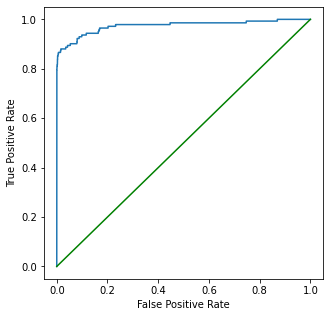

In [23]:
y_proba = SMOTETomek_rf.predict_proba(X_test)

from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay
def plot_auc_roc_curve(y_test, y_pred):
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
    roc_display.figure_.set_size_inches(5,5)
    plt.plot([0, 1], [0, 1], color = 'g')
# Plots the ROC curve using the sklearn methods - Good plot
plot_auc_roc_curve(y_test, y_proba[:, 1])
# Plots the ROC curve using the sklearn methods - Bad plot
#plot_sklearn_roc_curve(y_test, y_pred)

## 4.8 Precision-Recall Curve (PR curve)

The precision-recall curve shows the tradeoff between precision and recalls for different thresholds.

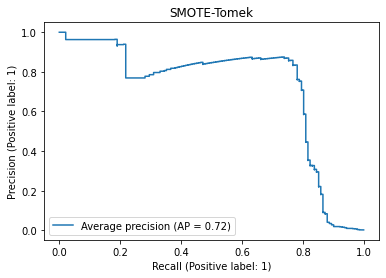

In [24]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    SMOTETomek_rf, X_test, y_test, name="Average precision")
_ = display.ax_.set_title("SMOTE-Tomek")

We can clearly see the point where we have to start trading a lot of Precision for better Recall score!

Average precision (AP) summarizes such a plot as the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold.

# 5. My other notebooks

Regression Models Evaluation Metrics

https://www.kaggle.com/code/marcinrutecki/regression-models-evaluation-metrics

Clustering methods - comprehensive study

https://www.kaggle.com/code/marcinrutecki/clustering-methods-comprehensive-study

Outlier detection methods!

https://www.kaggle.com/code/marcinrutecki/outlier-detection-methods

Multicollinearity - detection and remedies

https://www.kaggle.com/code/marcinrutecki/multicollinearity-detection-and-remedies

# 6. Refferals

https://deepchecks.com/top-techniques-for-cross-validation-in-machine-learning/

https://www.vevesta.com/blog/30-SMOTE-Tomek-Links?utm_souce=Substack-Tomek-Links

https://towardsdatascience.com/understanding-auc-roc-curve-68b2303cc9c5

https://towardsai.net/p/l/precision-recall-curve